<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/comparisonGbasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

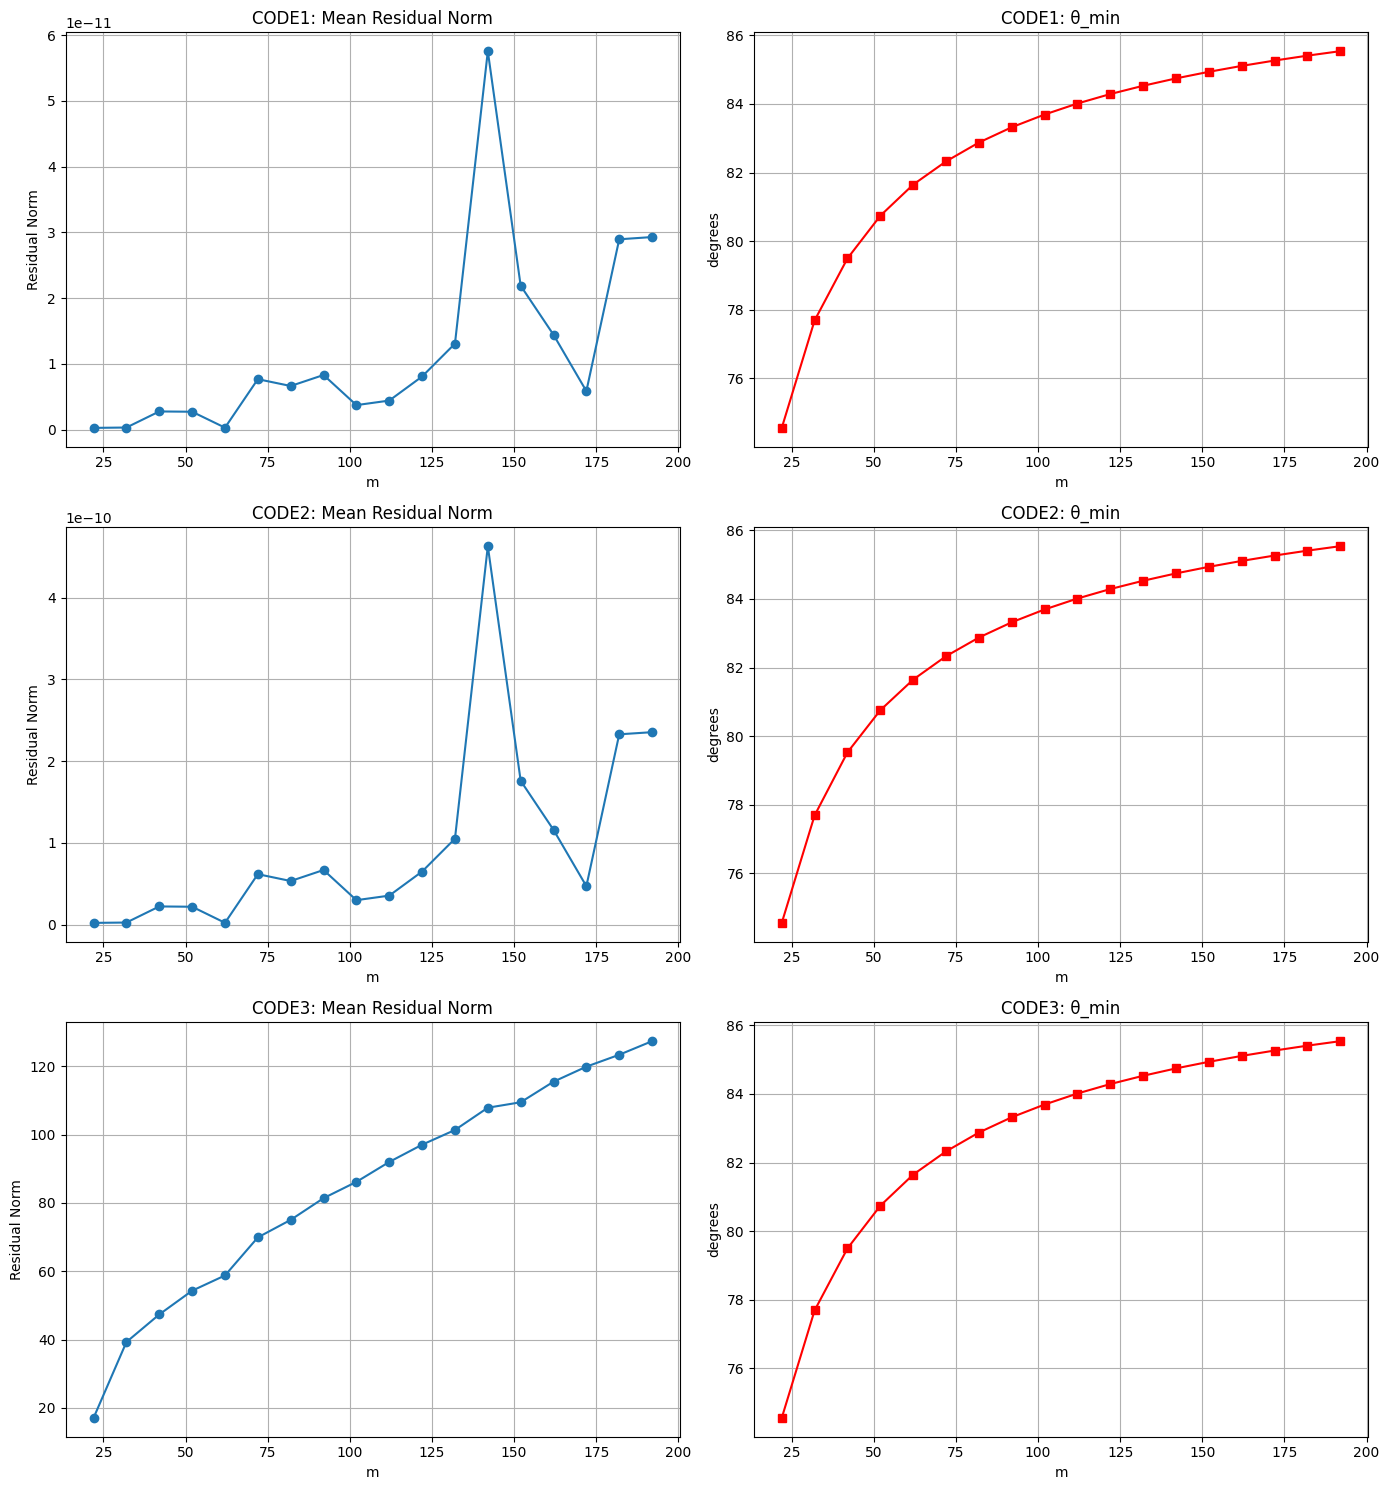

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# ----------------------------
# m values
# ----------------------------
m_values = np.arange(22, 202, 10)

# ----------------------------
# Prepare figure
# ----------------------------
plt.figure(figsize=(14, 15))  # 3 rows, 2 columns

# ============================
# CODE 1
# ============================
theta_min_vals = []
residual_mean_vals = []

for m in m_values:
    N = 4*m
    theta = 2*N - 1
    numVectors = N // 10

    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N, 1)
    l = np.arange(N).reshape(1, N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0) * (l - theta/2.0))

    C = np.real(G)
    S = np.imag(G)

    C2 = C @ C
    S2 = S @ S
    P_1  = 0.25*(C2 + C)
    P_m1 = 0.25*(C2 - C)
    P_i  = 0.25*(S2 + S)
    P_mi = 0.25*(S2 - S)

    X = P_1[:,0:m]
    Y = P_m1[:,0:m]
    Z = P_i[:,0:m]
    T = P_mi[:,0:m]

    diag_entries = np.hstack([np.ones(X.shape[1]), -np.ones(Y.shape[1]), 1j*np.ones(Z.shape[1]), -1j*np.ones(T.shape[1])])
    D = np.diag(diag_entries)
    V_G_cheby = np.hstack([X, Y, Z, T])

    # Residual norm
    diff1 = G @ V_G_cheby - V_G_cheby @ D
    residual_mean_vals.append(np.linalg.norm(diff1))

    # Minimum angle
    Vn = normalize_columns(V_G_cheby)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

plt.subplot(3,2,1)
plt.plot(m_values, residual_mean_vals, marker='o')
plt.title("CODE1: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Residual Norm")
plt.grid(True)

plt.subplot(3,2,2)
plt.plot(m_values, theta_min_vals, marker='s', color='red')
plt.title("CODE1: θ_min")
plt.xlabel("m")
plt.ylabel("degrees")
plt.grid(True)

# ============================
# CODE 2
# ============================
theta_min_vals = []
residual_mean_vals = []

for m in m_values:
    N = 4*m
    theta = 2*N - 1
    numVectors = N // 10

    w = np.exp(-2j * np.pi / N)
    G_theta = np.zeros((N,N), dtype=complex)
    for k in range(N):
        for l in range(N):
            G_theta[k,l] = (1/np.sqrt(N)) * w**((k-theta/2)*(l-theta/2))

    I = np.eye(N)
    G_squared = G_theta @ G_theta
    P_theta = 0.5*(I + G_squared)
    Q_theta = 0.5*(I - G_squared)

    P = np.real(P_theta)
    Q = np.real(Q_theta)
    C = np.real(G_theta)
    S = np.imag(G_theta)

    Phi = np.vstack([P[0:2*m,:], Q[2*m:N,:]])
    Phi_inv = np.linalg.inv(Phi)
    result = Phi @ C @ Phi_inv
    result1 = Phi @ S @ Phi_inv

    A = result[0:2*m,0:2*m]
    B = result1[2*m:N,2*m:N]

    X = A + np.eye(2*m)
    Y = A - np.eye(2*m)
    Z = B + np.eye(2*m)
    T = B - np.eye(2*m)

    X1 = X[:,0:m]
    Y1 = Y[:,0:m]
    Z1 = Z[:,0:m]
    T1 = T[:,0:m]

    X2 = np.vstack([X1, np.zeros((2*m, m))])
    Y2 = np.vstack([Y1, np.zeros((2*m, m))])
    Z2 = np.vstack([np.zeros((2*m, m)), Z1])
    T2 = np.vstack([np.zeros((2*m, m)), T1])

    X3 = np.linalg.inv(Phi) @ X2
    Y3 = np.linalg.inv(Phi) @ Y2
    Z3 = np.linalg.inv(Phi) @ Z2
    T3 = np.linalg.inv(Phi) @ T2

    V_G_reim = np.hstack([X3, Y3, Z3, T3])

    D = np.zeros((N,N), dtype=complex)
    for k in range(m):
        D[k,k] = 1
        D[m+k,m+k] = -1
        D[2*m+k,2*m+k] = 1j
        D[3*m+k,3*m+k] = -1j

    diff = G_theta @ V_G_reim - V_G_reim @ D
    residual_mean_vals.append(np.linalg.norm(diff))

    # Minimum angle
    Vn = normalize_columns(V_G_reim)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

plt.subplot(3,2,3)
plt.plot(m_values, residual_mean_vals, marker='o')
plt.title("CODE2: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Residual Norm")
plt.grid(True)

plt.subplot(3,2,4)
plt.plot(m_values, theta_min_vals, marker='s', color='red')
plt.title("CODE2: θ_min")
plt.xlabel("m")
plt.ylabel("degrees")
plt.grid(True)

# ============================
# CODE 3
# ============================
theta_min_vals = []
residual_mean_vals = []

for m in m_values:
    N = 4*m
    w = np.exp(-2j * np.pi / N)
    t = 2*N - 1
    numVectors = N // 10

    C = np.zeros((2*m, 2*m))
    S = np.zeros((2*m, 2*m))
    for k in range(1,2*m+1):
        for l in range(1,2*m+1):
            C[k-1,l-1] = (1/np.sqrt(N)) * np.cos((k-0.5)*(l-0.5)*2*np.pi/N)
            S[k-1,l-1] = (1/np.sqrt(N)) * np.sin((k-0.5)*(l-0.5)*2*np.pi/N)

    X = C + 0.5*np.eye(2*m)
    Y = C - 0.5*np.eye(2*m)
    Z = S + 0.5*np.eye(2*m)
    T = S - 0.5*np.eye(2*m)

    G = np.zeros((N,N), dtype=complex)
    for k in range(1,N+1):
        for l in range(1,N+1):
            G[k-1,l-1] = (1/np.sqrt(N)) * w**((k-1-t/2)*(l-1-t/2))

    J = np.flip(np.eye(2*m), axis=0)

    X1, Y1 = X[:,0:m], Y[:,0:m]
    Z1, T1 = Z[:,0:m], T[:,0:m]

    X2 = np.vstack([X1, -J @ X1])
    Y2 = np.vstack([Y1, -J @ Y1])
    Z2 = np.vstack([Z1, J @ Z1])
    T2 = np.vstack([T1, J @ T1])

    V_G_kernelmatrix = np.hstack([X2, Y2, T2, Z2])

    D = np.zeros((N,N), dtype=complex)
    for k in range(m):
        D[k,k] = 1
        D[m+k,m+k] = -1
        D[2*m+k,2*m+k] = 1j
        D[3*m+k,3*m+k] = -1j

    residuals = []
    for _ in range(numVectors):
        b = np.random.randn(N)*10
        x, _, _, _ = lstsq(V_G_kernelmatrix, b, rcond=None)
        residuals.append(np.linalg.norm(V_G_kernelmatrix @ x - b))
    residual_mean_vals.append(np.mean(residuals))

    Vn = normalize_columns(V_G_kernelmatrix)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

plt.subplot(3,2,5)
plt.plot(m_values, residual_mean_vals, marker='o')
plt.title("CODE3: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Residual Norm")
plt.grid(True)

plt.subplot(3,2,6)
plt.plot(m_values, theta_min_vals, marker='s', color='red')
plt.title("CODE3: θ_min")
plt.xlabel("m")
plt.ylabel("degrees")
plt.grid(True)

plt.tight_layout()
plt.show()
